In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [2]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:../mlruns")       # Dossier local des runs MLflow
mlflow.set_experiment("fraud_detection_experiment")   # Nom de l'expérience

c:\Users\insaf\fraud_detection_mlop\venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///c:/Users/insaf/fraud_detection_mlop/notebooks/../mlruns/657794680146510504', creation_time=1764275234118, experiment_id='657794680146510504', last_update_time=1764275234118, lifecycle_stage='active', name='fraud_detection_experiment', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [3]:
data = pd.read_csv("../data/raw/creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Shape :", data.shape)
print(data.isna().sum().sum(), "valeurs manquantes")
data["Class"].value_counts()

Shape : (284807, 31)
0 valeurs manquantes


Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
X = data.drop(columns=["Class"])
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size :", X_train.shape, "Test size :", X_test.shape)

Train size : (227845, 30) Test size : (56962, 30)


In [6]:
from sklearn.linear_model import LogisticRegression

with mlflow.start_run(run_name="LogReg_Baseline"):
    
    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(model, "model")

print("ROC-AUC Logistic Regression:", roc_auc)

c:\Users\insaf\fraud_detection_mlop\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2025/11/27 21:29:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/27 21:30:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


ROC-AUC Logistic Regression: 0.9725247601150758


In [7]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="RandomForest_200"):
    
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    
    rf_prob = rf_model.predict_proba(X_test)[:, 1]
    roc_auc_rf = roc_auc_score(y_test, rf_prob)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 8)
    mlflow.log_metric("roc_auc", roc_auc_rf)

    mlflow.sklearn.log_model(rf_model, "model")

print("ROC-AUC Random Forest:", roc_auc_rf)

2025/11/27 21:41:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/27 21:41:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


ROC-AUC Random Forest: 0.9796389416064681


[[56822    42]
 [   14    84]]


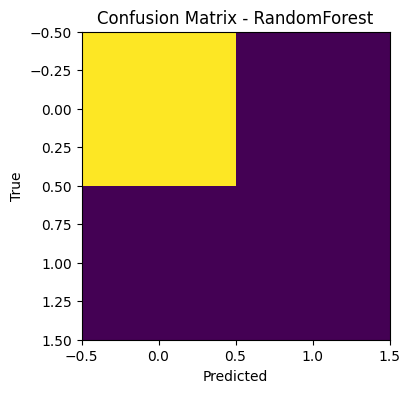

In [8]:
cm = confusion_matrix(y_test, rf_model.predict(X_test))
print(cm)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Confusion Matrix - RandomForest")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()